<a href="https://colab.research.google.com/github/sathkumara-smna/258739K/blob/main/site_power_ML_site_to_site.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# FULLY DATA-DRIVEN SITE-LEVEL ML MODEL
# AGGREGATE TRAFFIC FIRST
# NO ENGINEERING EQUATIONS
# NO MANUAL POWER PARAMETERS
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# LOAD EXCEL FILES FROM GITHUB
# ============================================================

site_db_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/Site%20Database%20from%20Sey.xlsx"
site_power_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/site_power%20from%20Sey.xlsx"
traffic_4g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/4G%20Traffic.xlsx"
traffic_5g_url = "https://raw.githubusercontent.com/sathkumara-smna/258739K/main/5G%20Traffic.xlsx"

# ============================================================
# READ EXCEL FILES
# ============================================================

site_db = pd.read_excel(site_db_url)
site_power = pd.read_excel(site_power_url)
traffic_4g = pd.read_excel(traffic_4g_url)
traffic_5g = pd.read_excel(traffic_5g_url)
site_db.head(2)

,#,Site_ID,Site Name,2G RRUs,3G RRUs,4G RRUs,5G AAUs,2G Boards,3G Boards,4G Boards,5G Boards,BBU 5900,BBU 3900,BBU 3910
0,1,101,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1
1,2,102,AIRPORT_PRASLIN,2,4,4,0,1,1,1,0,0,1,0


In [2]:
# ============================================================
# CONVERT DATETIME COLUMNS
# ============================================================

site_power['datetime'] = pd.to_datetime(
    site_power['datetime']
)

traffic_4g['datetime'] = pd.to_datetime(
    traffic_4g['datetime']
)

traffic_5g['datetime'] = pd.to_datetime(
    traffic_5g['datetime']
)
traffic_5g.head(2)

,Site_ID,Cell_ID,Sector_ID,trigger_ID,date,datetime,traffic_load_mbps
0,101,1011,1,1,2026-03-01,2026-03-01 00:00:00,61.20
1,101,1011,1,2,2026-03-01,2026-03-01 00:15:00,67.31


In [3]:
# ============================================================
# RENAME SITE DATABASE COLUMNS
# ============================================================

site_db.columns = [
    '#','Site_ID','Site_Name','RRU_2G','RRU_3G','RRU_4G','AAU_5G','Col_H','Col_I',
    'Boards_4G','Boards_5G','BBU5900','BBU3900','BBU3910']
site_db.head(2)

,#,Site_ID,Site_Name,RRU_2G,RRU_3G,RRU_4G,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910
0,1,101,AIRPORT_MAHE,3,7,12,3,1,2,2,1,1,1,1
1,2,102,AIRPORT_PRASLIN,2,4,4,0,1,1,1,0,0,1,0


In [4]:
# ============================================================
# CREATE TIME FEATURES
# ============================================================

site_power['hour'] = (
    site_power['datetime'].dt.hour
)

site_power['day_of_week'] = (
    site_power['datetime'].dt.dayofweek
)

In [5]:
# ============================================================
# AGGREGATE LTE TRAFFIC
# ============================================================

lte_traffic = (

    traffic_4g.groupby(
        ['Site_ID', 'trigger_ID', 'date', 'datetime'],
        as_index=False
    )['traffic_load_mbps']

    .sum()

)

lte_traffic.rename(
    columns={
        'traffic_load_mbps': 'total_4g_traffic'
    },
    inplace=True
)
lte_traffic.head(2)

,Site_ID,trigger_ID,date,datetime,total_4g_traffic
0,101,1,2026-03-01,2026-03-01,150.81
1,101,1,2026-03-02,2026-03-02,154.18


In [6]:
# ============================================================
# AGGREGATE NR TRAFFIC
# ============================================================
nr_traffic = (traffic_5g.groupby(['Site_ID', 'trigger_ID', 'date', 'datetime'],as_index=False)['traffic_load_mbps'].sum())
nr_traffic.rename(columns={'traffic_load_mbps': 'total_5g_traffic'},inplace=True)
nr_traffic.head(2)

,Site_ID,trigger_ID,date,datetime,total_5g_traffic
0,101,1,2026-03-01,2026-03-01,172.34
1,101,1,2026-03-02,2026-03-02,234.09


In [7]:
# ============================================================
# LTE CELL COUNTS
# ============================================================

lte_cell_counts = (

    traffic_4g.groupby('Site_ID')['Cell_ID']
    .nunique()
    .reset_index()

)

lte_cell_counts.rename(
    columns={'Cell_ID': 'lte_cell_count'},
    inplace=True
)
lte_cell_counts.head(2)

,Site_ID,lte_cell_count
0,101,12
1,102,4


In [8]:
# ============================================================
# NR CELL COUNTS
# ============================================================

nr_cell_counts = (

    traffic_5g.groupby('Site_ID')['Cell_ID']
    .nunique()
    .reset_index()

)

nr_cell_counts.rename(
    columns={'Cell_ID': 'nr_cell_count'},
    inplace=True
)
nr_cell_counts.head(2)

,Site_ID,nr_cell_count
0,101,3
1,103,3


In [9]:
# ============================================================
# MERGE ALL DATASETS
# ============================================================

final_df = site_power.merge(

    lte_traffic,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'

)

final_df = final_df.merge(

    nr_traffic,
    on=['Site_ID', 'trigger_ID', 'date', 'datetime'],
    how='left'
)

final_df = final_df.merge(

    lte_cell_counts,
    on='Site_ID',
    how='left'
)

final_df = final_df.merge(

    nr_cell_counts,
    on='Site_ID',
    how='left'
)

final_df = final_df.merge(

    site_db,
    on='Site_ID',
    how='left'

)
final_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,hour,day_of_week,total_4g_traffic,total_5g_traffic,lte_cell_count,...,RRU_3G,RRU_4G,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910
0,101,1,2026-03-01,2026-03-01 00:00:00,6517.6299,0,6,150.81,172.34,12,...,7,12,3,1,2,2,1,1,1,1
1,101,2,2026-03-01,2026-03-01 00:15:00,6533.5512,0,6,155.48,188.49,12,...,7,12,3,1,2,2,1,1,1,1


In [10]:
# ============================================================
# FILL NULL VALUES
# ============================================================

final_df.fillna(0, inplace=True)

# ============================================================
# FEATURES
# ============================================================

features = [

    'total_4g_traffic',
    'total_5g_traffic',

    'lte_cell_count',
    'nr_cell_count',

    'hour',
    'day_of_week',
    'trigger_ID',

    'RRU_2G',
    'RRU_3G',
    'RRU_4G',

    'AAU_5G',

    'Boards_4G',
    'Boards_5G',

    'BBU5900',
    'BBU3900',
    'BBU3910'

]

X = final_df[features]
y = final_df['site_power']
final_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,hour,day_of_week,total_4g_traffic,total_5g_traffic,lte_cell_count,...,RRU_3G,RRU_4G,AAU_5G,Col_H,Col_I,Boards_4G,Boards_5G,BBU5900,BBU3900,BBU3910
0,101,1,2026-03-01,2026-03-01 00:00:00,6517.6299,0,6,150.81,172.34,12,...,7,12,3,1,2,2,1,1,1,1
1,101,2,2026-03-01,2026-03-01 00:15:00,6533.5512,0,6,155.48,188.49,12,...,7,12,3,1,2,2,1,1,1,1


In [11]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42

)
print("Done")

Done


In [12]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

model = RandomForestRegressor(

    n_estimators=100,
    random_state=42

)

model.fit(X_train, y_train)
print("Done")

Done


In [13]:
# ============================================================
# PREDICTIONS
# ============================================================

predictions = model.predict(X_test)
print("Done")

Done


In [14]:
# ============================================================
# EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(

    y_test,
    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,
        predictions

    )

)

mape = np.mean(

    np.abs(

        (
            y_test - predictions
        )

        /

        y_test

    )

) * 100

r2 = r2_score(

    y_test,
    predictions

)
print("Done")

Done


In [15]:
# ============================================================
# PRINT RESULTS
# ============================================================

print('================================')
print('SITE-LEVEL ML PERFORMANCE')
print('================================')

print(f'MAE  : {round(mae, 2)}')
print(f'RMSE : {round(rmse, 2)}')
print(f'MAPE : {round(mape, 2)} %')
print(f'R2   : {round(r2, 4)}')

SITE-LEVEL ML PERFORMANCE
MAE  : 148.41
RMSE : 210.26
MAPE : 3.58 %
R2   : 0.9895


In [16]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

results_df = final_df.loc[

    X_test.index,

    [
        'Site_ID',
        'trigger_ID',
        'date',
        'datetime',
        'site_power'
    ]

].copy()

results_df['predicted_site_power'] = (
    predictions
)

results_df['error'] = (

    results_df['site_power'] -
    results_df['predicted_site_power']

)

results_df['error_percentage'] = (

    np.abs(results_df['error'])
    /
    results_df['site_power']

) * 100
results_df.head(2)

,Site_ID,trigger_ID,date,datetime,site_power,predicted_site_power,error,error_percentage
45078,120,55,2026-03-07,2026-03-07 13:30:00,2690.1552,2693.044833,-2.889633,0.107415
36590,107,15,2026-03-06,2026-03-06 03:30:00,2436.1100,2493.064445,-56.954445,2.337926


In [17]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    'Feature': features,
    'Importance': model.feature_importances_

})

importance_df = importance_df.sort_values(

    by='Importance',
    ascending=False

)

print('================================')
print('FEATURE IMPORTANCE')
print('================================')

print(importance_df)

FEATURE IMPORTANCE
             Feature  Importance
9             RRU_4G    0.512223
2     lte_cell_count    0.444642
8             RRU_3G    0.018034
1   total_5g_traffic    0.011663
0   total_4g_traffic    0.004226
7             RRU_2G    0.003700
15           BBU3910    0.002188
6         trigger_ID    0.001773
5        day_of_week    0.000907
4               hour    0.000461
13           BBU5900    0.000063
10            AAU_5G    0.000050
12         Boards_5G    0.000038
3      nr_cell_count    0.000024
11         Boards_4G    0.000007
14           BBU3900    0.000000


In [18]:
# ============================================================
# EXPORT RESULTS
# ============================================================

results_df.to_excel(

    'Fully_Data_Driven_Site_Level_Predictions.xlsx',
    index=False

)

print('================================')
print('OUTPUT FILE CREATED')
print('================================')

print('Fully_Data_Driven_Site_Level_Predictions.xlsx')

OUTPUT FILE CREATED
Fully_Data_Driven_Site_Level_Predictions.xlsx


In [19]:
# ============================================================
# SAMPLE RESULTS
# ============================================================

print(results_df.head(20))

       Site_ID  trigger_ID        date            datetime  site_power  \
45078      120          55  2026-03-07 2026-03-07 13:30:00   2690.1552   
36590      107          15  2026-03-06 2026-03-06 03:30:00   2436.1100   
9430       124          23  2026-03-02 2026-03-02 05:30:00   2914.9496   
7096       186          89  2026-03-01 2026-03-01 22:00:00   1840.9785   
20418      167          67  2026-03-03 2026-03-03 16:30:00   3222.1072   
3767       141          24  2026-03-01 2026-03-01 05:45:00   1951.0800   
14164      184          53  2026-03-02 2026-03-02 13:00:00   1948.9185   
48071      153          72  2026-03-07 2026-03-07 17:45:00   1776.2935   
20628      169          85  2026-03-03 2026-03-03 21:00:00   3917.9069   
508        106          29  2026-03-01 2026-03-01 07:00:00   2805.4440   
33864      155          73  2026-03-05 2026-03-05 18:00:00   2243.0815   
23417      119          90  2026-03-04 2026-03-04 22:15:00   2785.0596   
16084      118          53  2026-03-03

In [20]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

In [21]:
# ============================================================
# ERROR PERCENTAGE
# ============================================================

results_df['error_percentage'] = (

    np.abs(

        results_df['site_power']
        -
        results_df['predicted_site_power']

    )

    /

    results_df['site_power']

) * 100
print("Done")

Done


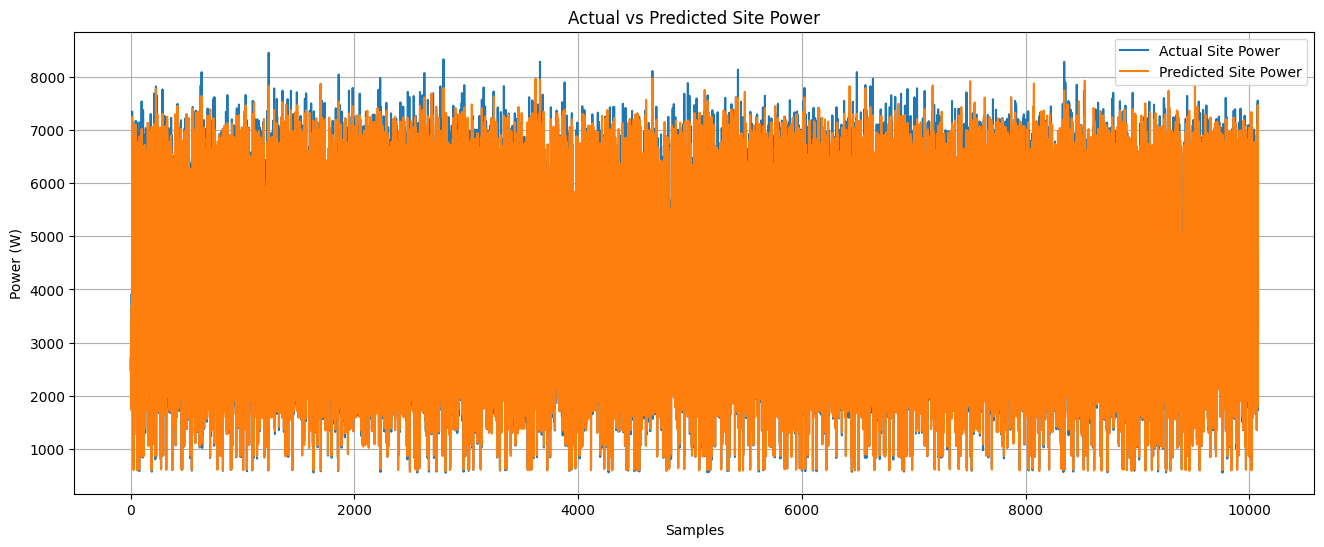

In [22]:
# ============================================================
# ACTUAL VS PREDICTED POWER GRAPH
# ============================================================

plt.figure(figsize=(16,6))

plt.plot(
    results_df['site_power'].values,
    label='Actual Site Power'
)

plt.plot(
    results_df['predicted_site_power'].values,
    label='Predicted Site Power'
)

plt.xlabel('Samples')
plt.ylabel('Power (W)')
plt.title('Actual vs Predicted Site Power')
plt.legend()
plt.grid(True)
plt.show()

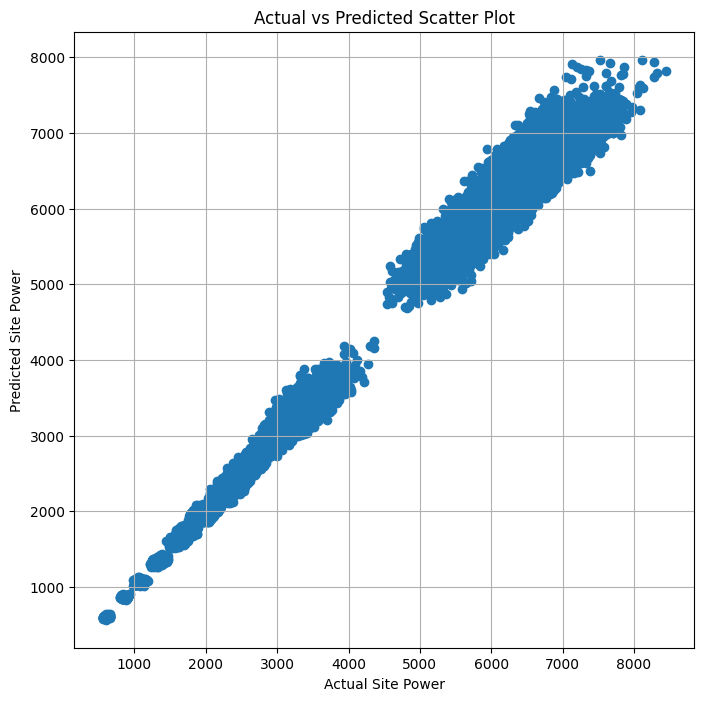

In [23]:
# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    results_df['site_power'],
    results_df['predicted_site_power']
)

plt.xlabel('Actual Site Power')
plt.ylabel('Predicted Site Power')
plt.title('Actual vs Predicted Scatter Plot')
plt.grid(True)
plt.show()

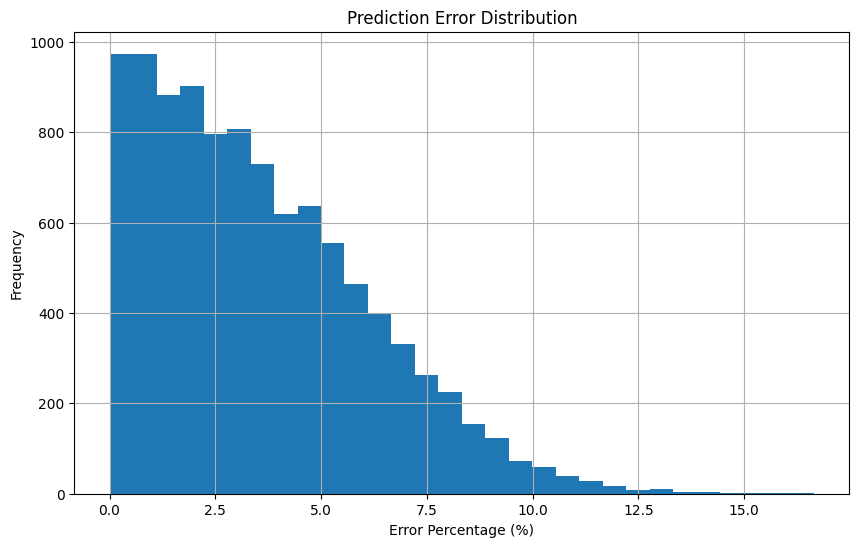

In [24]:
# ============================================================
# ERROR PERCENTAGE HISTOGRAM
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(
    results_df['error_percentage'],
    bins=30
)

plt.xlabel('Error Percentage (%)')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')
plt.grid(True)
plt.show()

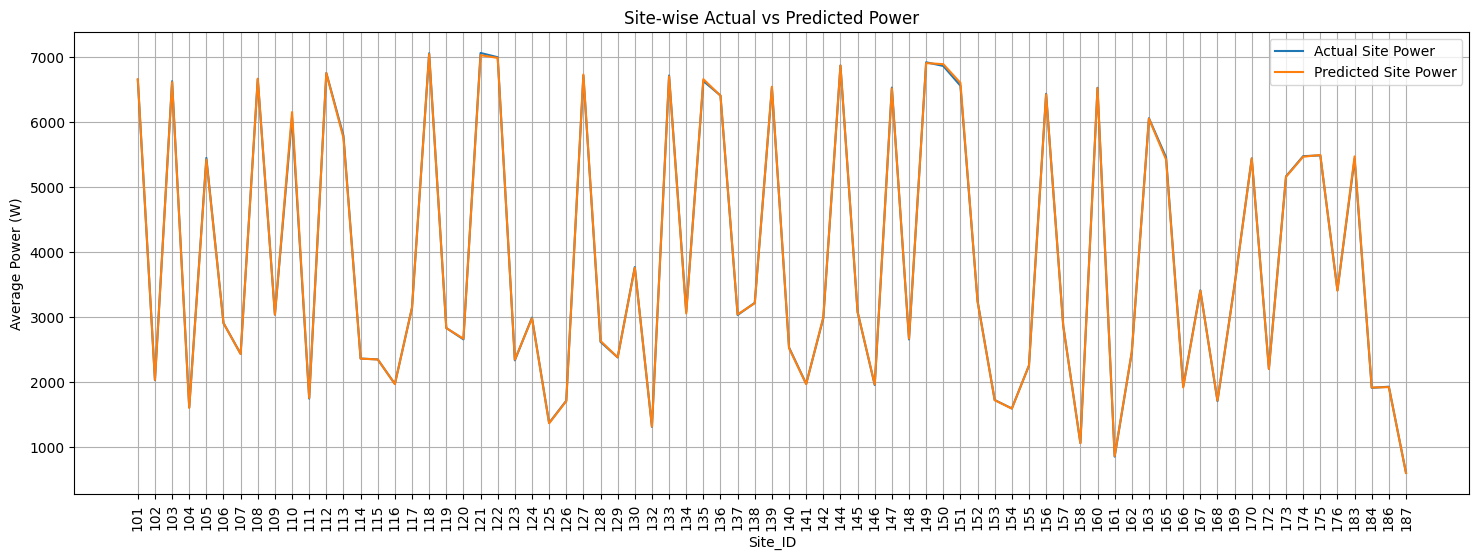

In [25]:
# ============================================================
# SITE-WISE ACTUAL VS PREDICTED POWER
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# SITE-WISE AVERAGE POWER
# ============================================================

sitewise_df = (results_df.groupby('Site_ID')[['site_power','predicted_site_power']].mean().reset_index())

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(
    sitewise_df['Site_ID'].astype(str),
    sitewise_df['site_power'],
    label='Actual Site Power'
)

plt.plot(
    sitewise_df['Site_ID'].astype(str),
    sitewise_df['predicted_site_power'],
    label='Predicted Site Power'

)

plt.xlabel('Site_ID')
plt.ylabel('Average Power (W)')
plt.title('Site-wise Actual vs Predicted Power')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

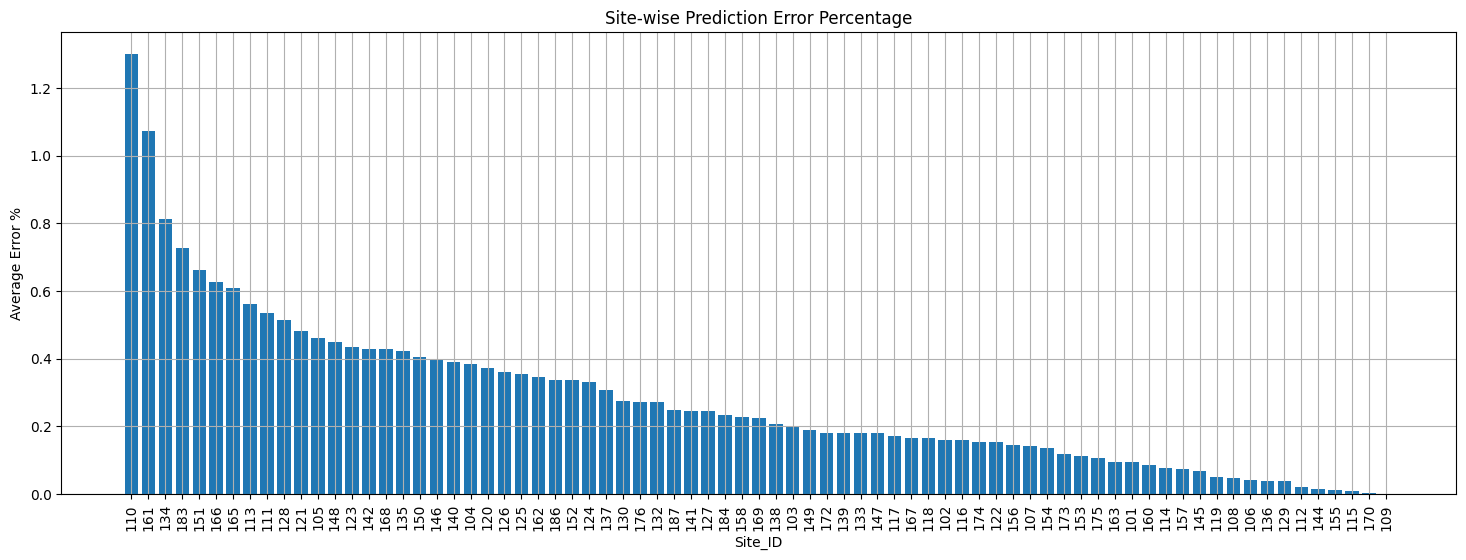

In [26]:
# ============================================================
# SITE-WISE ERROR ANALYSIS
# ============================================================

sitewise_error = (

    results_df.groupby('Site_ID')[

        [
            'site_power',
            'predicted_site_power'
        ]

    ]

    .mean()

    .reset_index()

)

# ============================================================
# ABSOLUTE ERROR
# ============================================================

sitewise_error['absolute_error'] = (

    abs(

        sitewise_error['site_power']
        -
        sitewise_error['predicted_site_power']

    )

)

# ============================================================
# ERROR PERCENTAGE
# ============================================================

sitewise_error['error_percentage'] = (

    sitewise_error['absolute_error']
    /
    sitewise_error['site_power']

) * 100

# ============================================================
# SORT BY ERROR
# ============================================================

sitewise_error = sitewise_error.sort_values(
    by='error_percentage',
    ascending=False
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(18,6))

plt.bar(

    sitewise_error['Site_ID'].astype(str),
    sitewise_error['error_percentage']

)

plt.xlabel('Site_ID')
plt.ylabel('Average Error %')
plt.title('Site-wise Prediction Error Percentage')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

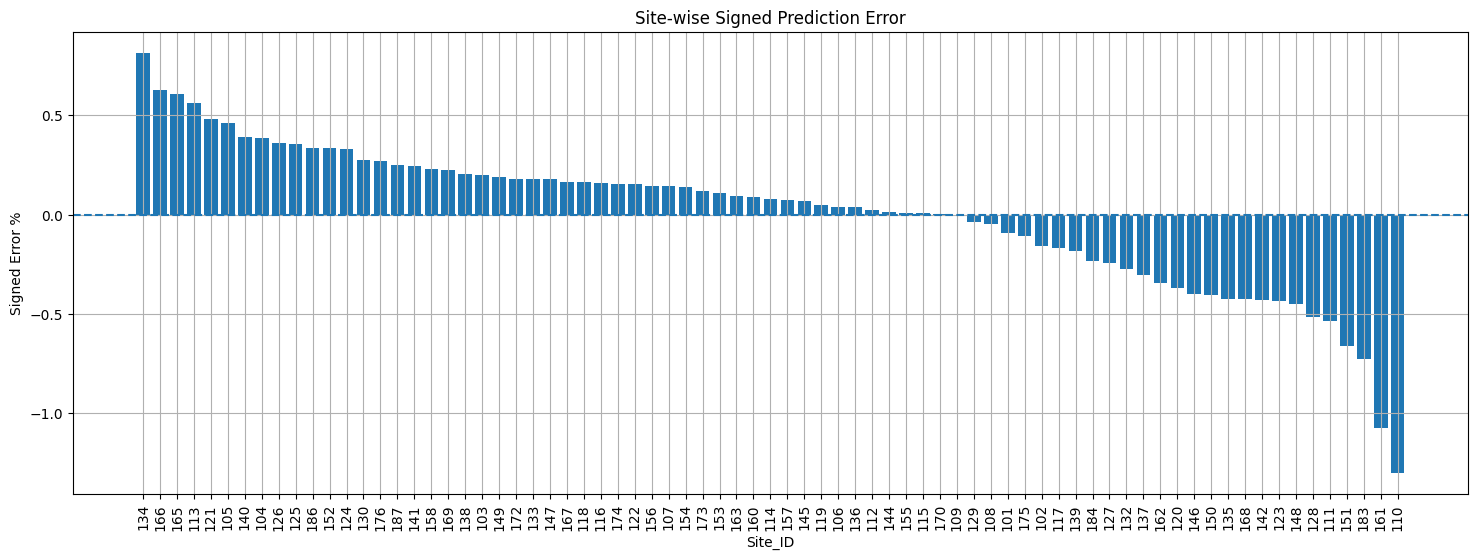

In [27]:
# ============================================================
# SITE-WISE SIGNED ERROR ANALYSIS
# ============================================================

sitewise_error = (

    results_df.groupby('Site_ID')[

        [
            'site_power',
            'predicted_site_power'
        ]

    ]

    .mean()

    .reset_index()

)

# ============================================================
# SIGNED ERROR
# ============================================================

sitewise_error['signed_error'] = (

    sitewise_error['site_power']
    -
    sitewise_error['predicted_site_power']

)

# ============================================================
# ERROR PERCENTAGE
# ============================================================

sitewise_error['signed_error_percentage'] = (

    sitewise_error['signed_error']
    /
    sitewise_error['site_power']

) * 100

# ============================================================
# SORT
# ============================================================

sitewise_error = sitewise_error.sort_values(
    by='signed_error_percentage',
    ascending=False
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(18,6))

plt.bar(

    sitewise_error['Site_ID'].astype(str),
    sitewise_error['signed_error_percentage']

)

# Zero reference line

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Site_ID')
plt.ylabel('Signed Error %')
plt.title('Site-wise Signed Prediction Error')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()